In [1]:
# general
import numpy as np
from numpy.random import PCG64, SeedSequence
import pandas as pd
import verde as vd
import harmonica as hm
from scipy import interpolate
import xarray as xr
import cmocean
from cmcrameri import cm
import geopandas as gpd
from skgstat import models
import gstatsim as gsm
from scipy.stats import mstats

# plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import animation

# io
from tqdm.auto import tqdm
import os
from pathlib import Path
import time

import sys
sys.path.append('../../src')

from flowline import flowline

In [2]:
name = 'larsen'
bm_path = Path('../../raw_data/BedMachineAntarctica-v4.nc')
vel_path = Path('../../raw_data/antarctic_ice_vel_phase_map_v01.nc')

In [3]:
ds = xr.load_dataset('larsen.nc')
ensemble = xr.load_dataarray(Path('results/ensemble_geoid_2000.nc'))

ensemble_mean = np.mean(ensemble.values, axis=0)
ensemble_std = np.std(ensemble.values, axis=0)
ensemble_diff = ds.bed-np.mean(ensemble.values, axis=0)

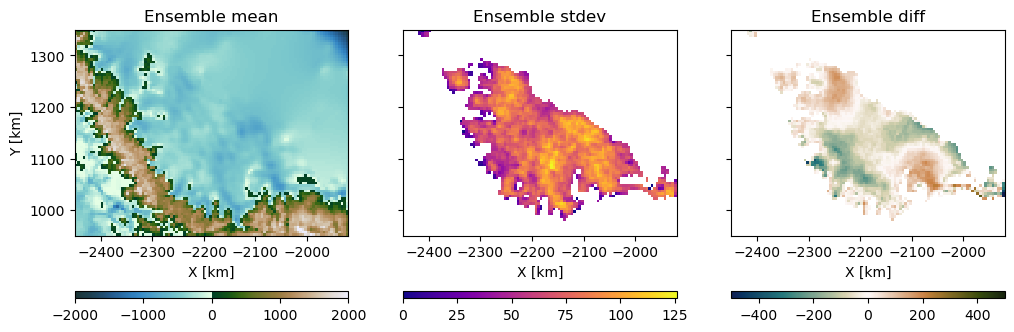

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(12,6), sharey=True)
ax = axs[0]
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, ensemble_mean, vmin=-2000, vmax=2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Ensemble mean')
plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, np.where(ds.inv_msk, ensemble_std, np.nan), vmin=0, cmap='plasma')
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Ensemble stdev')
plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, np.where(ds.inv_msk, ensemble_diff, np.nan), vmin=-500, vmax=500, cmap='cmo.tarn_r')
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Ensemble diff')
plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, aspect=40)

plt.show()

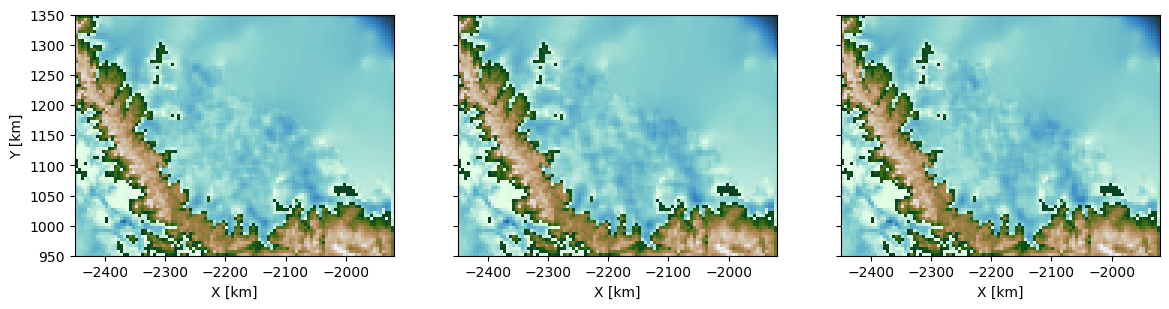

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(14,6), sharey=True)

for i, ax in enumerate(axs):
    ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, ensemble.sel(i=i), vmin=-2000, vmax=2000, cmap=cm.bukavu)
    ax.axis('scaled')
axs[0].set_ylabel('Y [km]')
axs[0].set_xlabel('X [km]')
axs[1].set_xlabel('X [km]')
axs[2].set_xlabel('X [km]')
plt.show()

In [6]:
grid = xr.open_dataset(bm_path)

xx, yy = np.meshgrid(ds.x, ds.y)

# trim original BedMachine, get coordinates
x_trim = (grid.x >= np.min(xx)) & (grid.x <= np.max(xx))
y_trim = (grid.y >= np.min(yy)) & (grid.y <= np.max(yy))
grid = grid.sel(x=x_trim, y=y_trim)
xx_bm, yy_bm = np.meshgrid(grid.x.values, grid.y.values)

# interpolate inversion mask to original resolution
kn = vd.KNeighbors(1)
kn.fit((xx.flatten(), yy.flatten()), ds.inv_msk.values.flatten())
preds_msk = kn.predict((xx_bm, yy_bm))
preds_msk = preds_msk.reshape(xx_bm.shape) > 0.5

ensemble = xr.load_dataarray(Path('results/ensemble_geoid_500.nc'))

ensemble_mean = np.mean(ensemble.values, axis=0)
ensemble_std = np.std(ensemble.values, axis=0)
ensemble_diff = grid.bed-np.mean(ensemble.values, axis=0)

xx_dens, yy_dens = np.meshgrid(grid.x, grid.y)

kn = vd.KNeighbors(1)
kn.fit((xx.flatten(), yy.flatten()), ds.inv_msk.values.flatten())
preds = kn.predict((xx_dens, yy_dens))
inv_dens = preds.reshape(xx_dens.shape) > 0.5

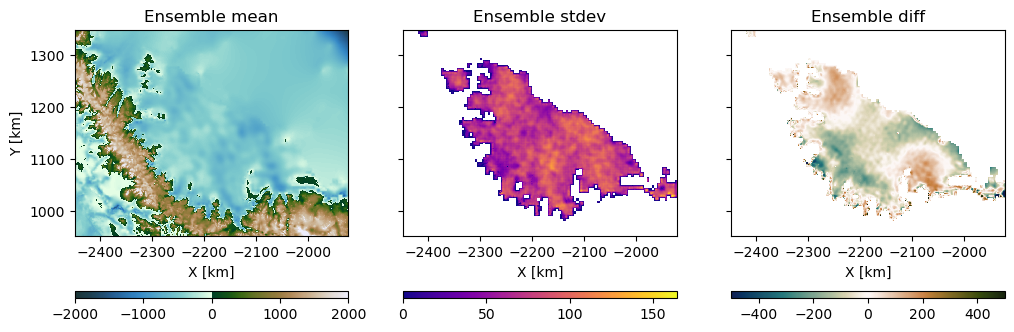

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12,6), sharey=True)
ax = axs[0]
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, ensemble_mean, vmin=-2000, vmax=2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Ensemble mean')
plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, np.where(preds_msk, ensemble_std, np.nan), vmin=0, cmap='plasma')
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Ensemble stdev')
plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, np.where(preds_msk, ensemble_diff, np.nan), vmin=-500, vmax=500, cmap='cmo.tarn_r')
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Ensemble diff')
plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, aspect=40)

plt.show()

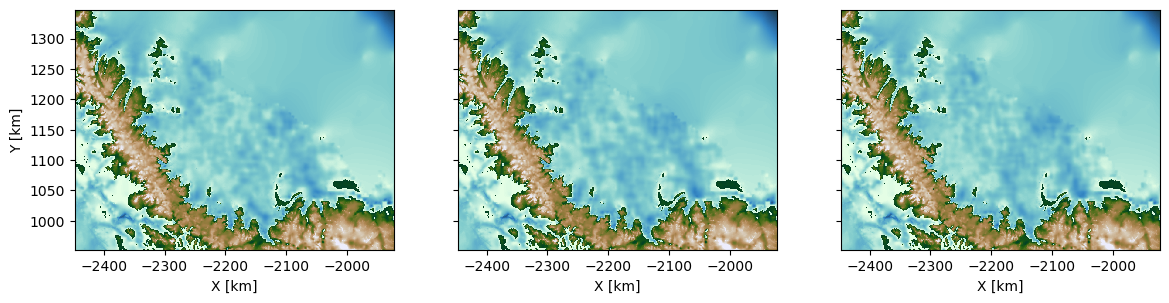

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(14,6), sharey=True)

for i, ax in enumerate(axs):
    ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, ensemble.sel(i=i), vmin=-2000, vmax=2000, cmap=cm.bukavu)
    ax.axis('scaled')
axs[0].set_ylabel('Y [km]')
axs[0].set_xlabel('X [km]')
axs[1].set_xlabel('X [km]')
axs[2].set_xlabel('X [km]')
plt.show()

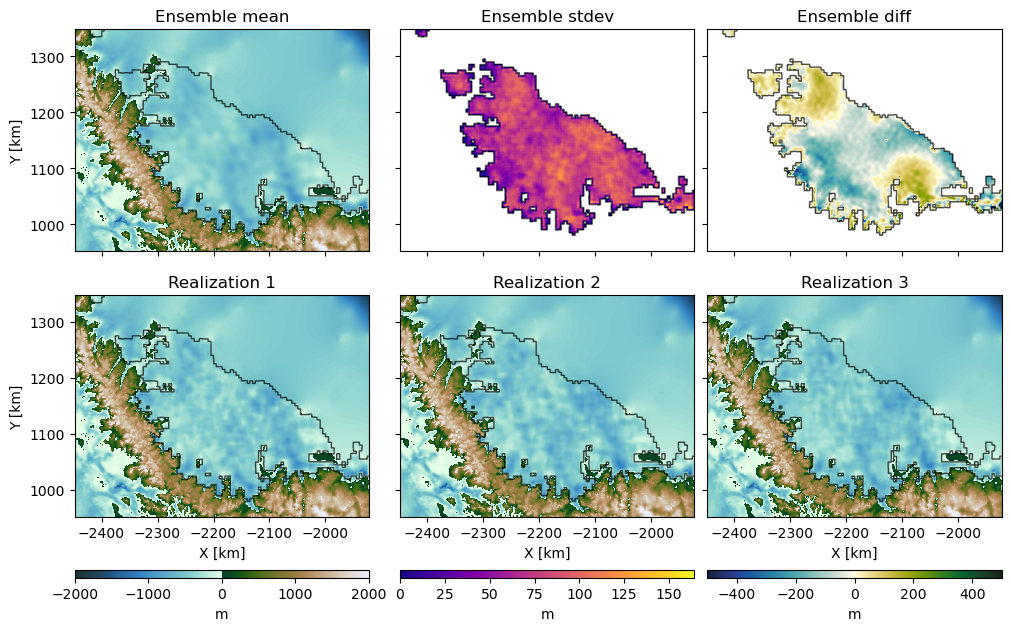

In [9]:
fig = plt.figure(figsize=(10,6.2), constrained_layout=True)

gs = GridSpec(3, 3, figure=fig, height_ratios=[1,1,0.03], hspace=0.05)

ax = fig.add_subplot(gs[0,0])
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, ensemble_mean, vmin=-2000, vmax=2000, cmap=cm.bukavu, rasterized=True)
ax.axis('scaled')
ax.set_ylabel('Y [km]')
ax.set_title('Ensemble mean')
ax.set_xticklabels([])
cax = fig.add_subplot(gs[2,0])
plt.colorbar(im, cax=cax, orientation='horizontal', pad=0.12, aspect=40, label='m')
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)

ax = fig.add_subplot(gs[0,1])
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, np.where(preds_msk, ensemble_std, np.nan), vmin=0, cmap='plasma', rasterized=True)
ax.axis('scaled')
ax.set_title('Ensemble stdev')
ax.set_xticklabels([])
ax.set_yticklabels([])
cax = fig.add_subplot(gs[2,1])
plt.colorbar(im, cax=cax, orientation='horizontal', pad=0.12, aspect=40, label='m')
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)

ax = fig.add_subplot(gs[0,2])
im = ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, np.where(preds_msk, ensemble_diff, np.nan), vmin=-500, vmax=500, cmap='cmo.delta', rasterized=True)
ax.axis('scaled')
ax.set_title('Ensemble diff')
ax.set_xticklabels([])
ax.set_yticklabels([])
cax = fig.add_subplot(gs[2,2])
plt.colorbar(im, cax=cax, orientation='horizontal', pad=0.12, aspect=40, label='m')
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)

axs = []
for i in range(3):
    axs.append(fig.add_subplot(gs[1,i]))

for i, ax in enumerate(axs):
    ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, ensemble.sel(i=i), vmin=-2000, vmax=2000, cmap=cm.bukavu, rasterized=True)
    ax.axis('scaled')
    ax.set_title(f'Realization {i+1}')
    cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)
axs[0].set_ylabel('Y [km]')
axs[0].set_xlabel('X [km]')
axs[1].set_xlabel('X [km]')
axs[2].set_xlabel('X [km]')
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])

plt.savefig(Path(f'../../figures/png/{name}_combo.png'), dpi=300, bbox_inches='tight')
plt.savefig(Path(f'../../figures/svg/{name}_combo.svg'), dpi=300, bbox_inches='tight')
plt.show()

In [10]:
xmin = ds.x.values.min()
xmax = ds.x.values.max()
ymin = ds.y.values.min()
ymax = ds.y.values.max()

vel = xr.open_dataset(vel_path)
vel = vel.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))
vel

<xarray.Dataset>
Dimensions:       (x: 1167, y: 878)
Coordinates:
  * x             (x) float64 -2.447e+06 -2.447e+06 ... -1.923e+06 -1.922e+06
  * y             (y) float64 1.347e+06 1.347e+06 ... 9.532e+05 9.528e+05
    lat           (y, x) float64 ...
    lon           (y, x) float64 ...
Data variables:
    coord_system  |S1 ...
    VX            (y, x) float32 ...
    VY            (y, x) float32 ...
    STDX          (y, x) float32 ...
    STDY          (y, x) float32 ...
    ERRX          (y, x) float32 ...
    ERRY          (y, x) float32 ...
    CNT           (y, x) int32 ...
    SOURCE        (y, x) int8 ...
Attributes: (12/27)
    Conventions:               CF-1.6
    Metadata_Conventions:      CF-1.6, Unidata Dataset Discovery v1.0, GDS v2.0
    standard_name_vocabulary:  CF Standard Name Table (v22, 12 February 2013)
    id:                        v_mix.v8Jul2019.nc
    title:                     MEaSURES Antarctica Ice Velocity Map 450m spacing
    product_version:            
    ...                        ...
    time_coverage_start:       1995-01-01
    time_coverage_end:         2016-12-31
    project:                   NASA/MEaSUREs
    creator_name:              J. Mouginot
    comment:                    
    license:                   No restrictions on access or use.

In [11]:
vmag = np.sqrt(vel.VX**2+vel.VY**2)

In [12]:
vel_coarse = vel.coarsen(x=25, y=25, boundary='trim').mean()
xx_coarse, yy_coarse = np.meshgrid(vel_coarse.x, vel_coarse.y)

def transform(u, v):
    """
    Log transform quiver arrow lengths
    """
    arrow_lengths = np.sqrt(u*u + v*v)
    len_adjust_factor = np.log10(arrow_lengths + 1) / arrow_lengths
    return u*len_adjust_factor, v*len_adjust_factor

u_log, v_log = transform(vel_coarse.VX, vel_coarse.VY)

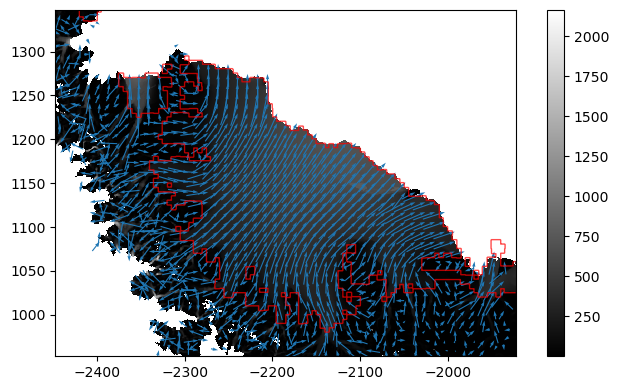

In [13]:
plt.figure(figsize=(8,4.5))
im = plt.pcolormesh(vel.x/1000, vel.y/1000, vmag, cmap='gray')
plt.quiver(xx_coarse/1000, yy_coarse/1000, u_log, v_log, color='tab:blue', angles='xy', 
           headwidth=3, pivot='tip', scale=50)
plt.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='r', antialiased=True, linewidths=1, alpha=0.7)
plt.axis('scaled')
plt.colorbar(im)
plt.show()


In [14]:
xx_vel, yy_vel = np.meshgrid(vel.x, vel.y)

vx = vel.VX.values
vy = vel.VY.values

In [15]:
from scipy.interpolate import griddata

def bedmachine_profile(bm, pred_coords, beds, quantiles=(0.05, 0.95)):
    xx, yy = np.meshgrid(bm.x.values, bm.y.values)
    
    coordinates = np.array([xx.flatten(), yy.flatten()]).T
    
    # use data within 10 km of profile for interpolation
    dist_msk = vd.distance_mask((pred_coords[:,0], pred_coords[:,1]), 10e3, (xx.flatten(), yy.flatten()))
    coordinates = coordinates[dist_msk,:]
    
    bed_profile = griddata(coordinates, bm.bed.values.flatten()[dist_msk], pred_coords)
    surf_profile = griddata(coordinates, bm.surface.values.flatten()[dist_msk], pred_coords)
    thick_profile = griddata(coordinates, bm.thickness.values.flatten()[dist_msk], pred_coords)

    beds_profiles = np.zeros((beds.shape[0], pred_coords.shape[0]))
    for i in tqdm(range(beds.shape[0])):
            beds_profiles[i] =  griddata(coordinates, beds[i].flatten()[dist_msk], pred_coords)

    mean_profile = np.mean(beds_profiles, axis=0)
    std_profile = np.std(beds_profiles, axis=0)
    
    thick_profile = np.where(mean_profile > surf_profile-thick_profile, surf_profile-mean_profile, thick_profile)

    quants = mstats.mquantiles(beds_profiles, prob=quantiles, axis=0)
        
    return bed_profile, surf_profile, thick_profile, beds_profiles, mean_profile, quants

In [16]:
x0 = -2.12e6
y0 = 0.96e6

# x0 = -2.06e6
# y0 = 1.02e6

flow_dist_forward, dists = flowline(xx_vel, yy_vel, vx, vy, x0, y0, stride=200, mode='distance', total_dist=280e3, maxdist=5e3, extend=50, max_iter=1500)
print(f'{flow_dist_forward.shape[0]} points')

bed_profile, surf_profile, thick_profile, beds, mean_profile, quants = bedmachine_profile(grid, flow_dist_forward[::-1,:], ensemble.values)

1257 points


  0%|          | 0/100 [00:00<?, ?it/s]

In [17]:
dists /= 1000

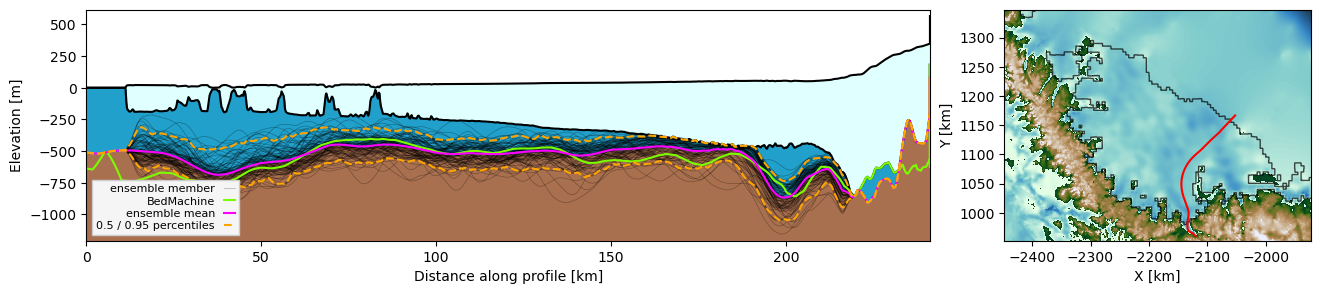

In [18]:
water_color = '#21a0cb'
ice_color = 'lightcyan'
rock_color = '#a9704f'

ylow = 300

fig, axs = plt.subplots(1, 2, figsize=(16,3), gridspec_kw=dict(width_ratios=[1, 0.4], wspace=0.1))
ax = axs[0]
ax.fill_between(dists, surf_profile-thick_profile, surf_profile, color=ice_color, rasterized=True)
ax.fill_between(dists, np.full(len(dists), np.min(mean_profile))-ylow, mean_profile, color=rock_color, rasterized=True)
ax.fill_between(dists, mean_profile, surf_profile-thick_profile, color=water_color, rasterized=True)
ax.plot(dists, surf_profile, c='k')
ax.plot(dists, surf_profile-thick_profile, c='k')

ax.set_xlim(0, dists[-1])
ax.set_ylim(np.min(mean_profile)-ylow, np.max(surf_profile)+50)
ax.set_xlabel('Distance along profile [km]')
ax.set_ylabel('Elevation [m]')

ax.plot(dists, beds[0], c='k', alpha=0.3, linewidth=0.5, label='ensemble member')
for i in range(1, beds.shape[0]):
    ax.plot(dists, beds[i], c='k', alpha=0.3, linewidth=0.5)

ax.plot(dists, bed_profile, c='lawngreen', label='BedMachine')
ax.plot(dists, mean_profile, c='magenta', label='ensemble mean')
ax.plot(dists, quants[0], c='orange', linestyle='dashed', label='0.5 / 0.95 percentiles')
ax.plot(dists, quants[1], c='orange', linestyle='dashed')

ax.legend(framealpha=1, fontsize=8, loc='lower left', fancybox=False, handlelength=1., frameon=True, facecolor='whitesmoke', 
                markerfirst=False, labelspacing=0.2)

ax = axs[1]
ax.pcolormesh(ensemble.x/1000, ensemble.y/1000, ensemble_mean, cmap=cm.bukavu, vmin=-2000, vmax=2000, rasterized=True)
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)
ax.plot(flow_dist_forward[:,0]/1000, flow_dist_forward[:,1]/1000, 'r-')
ax.axis('scaled')
ax.set_ylabel('Y [km]')
ax.set_xlabel('X [km]')

plt.savefig(Path(f'../../figures/png/{name}_profile.png'), dpi=300, bbox_inches='tight')
plt.savefig(Path(f'../../figures/svg/{name}_profile.svg'), dpi=300, bbox_inches='tight')
plt.show()

# Regularized Gauss Newton

In [19]:
import postprocessing
import utilities
import importlib
importlib.reload(postprocessing)
importlib.reload(utilities)

from postprocessing import get_beds, upscale_beds, hub_elevations

In [20]:
beds = xr.open_dataarray(Path('results_gn/ensemble_geoid_5000.nc')).values
beds_up = xr.open_dataarray(Path('results_gn/ensemble_geoid_500.nc')).values
hubs = xr.open_dataarray(Path('hubs/ensemble_hubs.nc')).values
beds_up.shape

(200, 791, 1051)

In [21]:
grid = xr.open_dataset(bm_path)

xx, yy = np.meshgrid(ds.x, ds.y)

# trim original BedMachine, get coordinates
x_trim = (grid.x >= np.min(xx)) & (grid.x <= np.max(xx))
y_trim = (grid.y >= np.min(yy)) & (grid.y <= np.max(yy))
grid = grid.sel(x=x_trim, y=y_trim)
xx_bm, yy_bm = np.meshgrid(grid.x.values, grid.y.values)

# interpolate inversion mask to original resolution
kn = vd.KNeighbors(1)
kn.fit((xx.flatten(), yy.flatten()), ds.inv_msk.values.flatten())
inv_dens = kn.predict((xx_bm, yy_bm))
inv_dens = inv_dens.reshape(xx_bm.shape) > 0.5

In [22]:
ensemble_mean = np.mean(beds_up, axis=0)
ensemble_std = np.std(beds_up, axis=0)
ensemble_diff = grid.bed.values - ensemble_mean

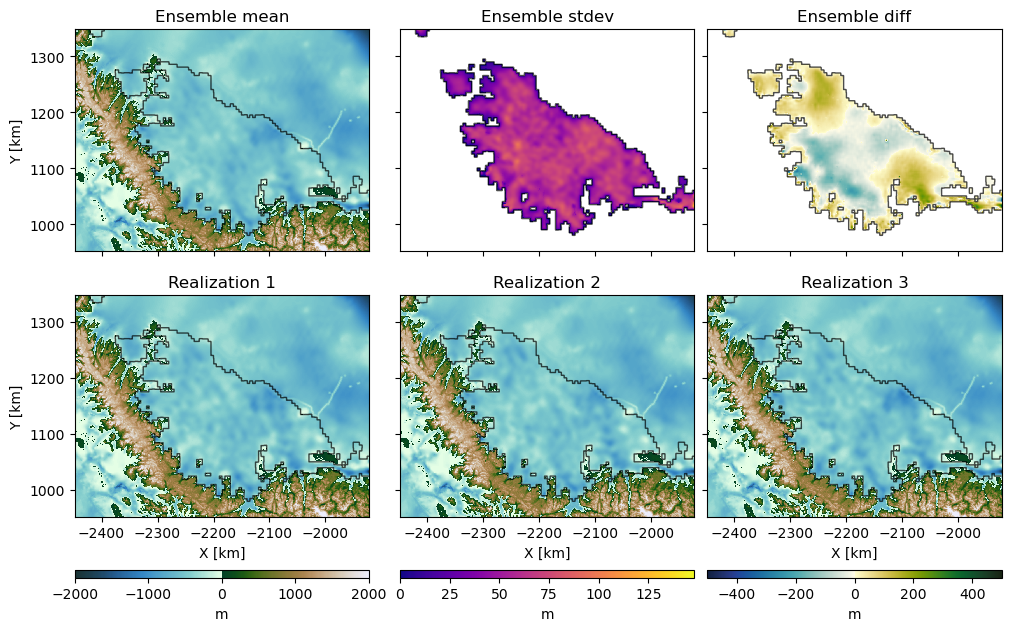

In [23]:
fig = plt.figure(figsize=(10,6.2), constrained_layout=True)

gs = GridSpec(3, 3, figure=fig, height_ratios=[1,1,0.03], hspace=0.05)

ax = fig.add_subplot(gs[0,0])
im = ax.pcolormesh(grid.x/1000, grid.y/1000, ensemble_mean, vmin=-2000, vmax=2000, cmap=cm.bukavu, rasterized=True)
ax.axis('scaled')
ax.set_ylabel('Y [km]')
ax.set_title('Ensemble mean')
ax.set_xticklabels([])
cax = fig.add_subplot(gs[2,0])
plt.colorbar(im, cax=cax, orientation='horizontal', pad=0.12, aspect=40, label='m')
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)

ax = fig.add_subplot(gs[0,1])
im = ax.pcolormesh(grid.x/1000, grid.y/1000, np.where(inv_dens, ensemble_std, np.nan), vmin=0, cmap='plasma', rasterized=True)
ax.axis('scaled')
ax.set_title('Ensemble stdev')
ax.set_xticklabels([])
ax.set_yticklabels([])
cax = fig.add_subplot(gs[2,1])
plt.colorbar(im, cax=cax, orientation='horizontal', pad=0.12, aspect=40, label='m')
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)

ax = fig.add_subplot(gs[0,2])
im = ax.pcolormesh(grid.x/1000, grid.y/1000, np.where(inv_dens, ensemble_diff, np.nan), vmin=-500, vmax=500, cmap='cmo.delta', rasterized=True)
ax.axis('scaled')
ax.set_title('Ensemble diff')
ax.set_xticklabels([])
ax.set_yticklabels([])
cax = fig.add_subplot(gs[2,2])
plt.colorbar(im, cax=cax, orientation='horizontal', pad=0.12, aspect=40, label='m')
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)

axs = []
for i in range(3):
    axs.append(fig.add_subplot(gs[1,i]))

for i, ax in enumerate(axs):
    ax.pcolormesh(grid.x/1000, grid.y/1000, beds_up[i,...], vmin=-2000, vmax=2000, cmap=cm.bukavu, rasterized=True)
    ax.axis('scaled')
    ax.set_title(f'Realization {i+1}')
    cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)
axs[0].set_ylabel('Y [km]')
axs[0].set_xlabel('X [km]')
axs[1].set_xlabel('X [km]')
axs[2].set_xlabel('X [km]')
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])

plt.savefig(Path(f'../../figures/png/{name}_combo.png'), dpi=300, bbox_inches='tight')
plt.savefig(Path(f'../../figures/svg/{name}_combo.svg'), dpi=300, bbox_inches='tight')
plt.show()

In [24]:
x0 = -2.12e6
y0 = 0.96e6

# x0 = -2.06e6
# y0 = 1.02e6

flow_dist_forward, dists = flowline(xx_vel, yy_vel, vx, vy, x0, y0, stride=200, mode='distance', total_dist=280e3, maxdist=5e3, extend=50, max_iter=1500)
print(f'{flow_dist_forward.shape[0]} points')

bed_profile, surf_profile, thick_profile, beds_profiles, mean_profile, quants = bedmachine_profile(grid, flow_dist_forward[::-1,:], beds_up)

1257 points


  0%|          | 0/200 [00:00<?, ?it/s]

In [25]:
dists /= 1000

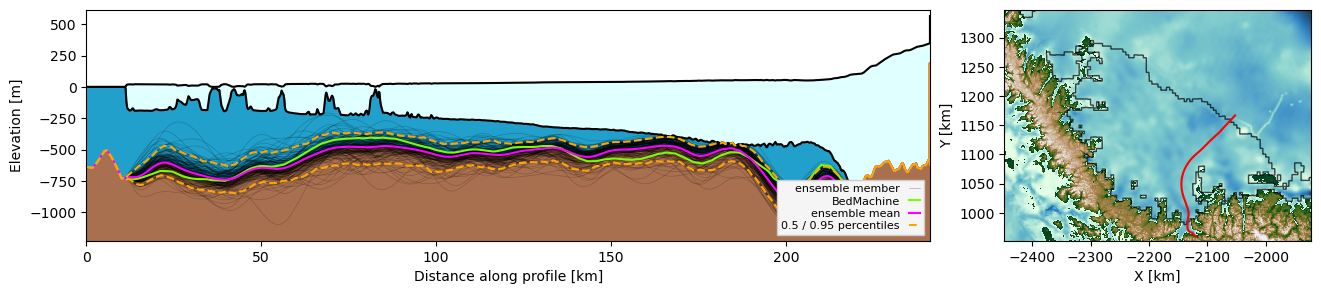

In [26]:
water_color = '#21a0cb'
ice_color = 'lightcyan'
rock_color = '#a9704f'

ylow = 300

fig, axs = plt.subplots(1, 2, figsize=(16,3), gridspec_kw=dict(width_ratios=[1, 0.4], wspace=0.1))
ax = axs[0]
ax.fill_between(dists, surf_profile-thick_profile, surf_profile, color=ice_color, rasterized=True)
ax.fill_between(dists, np.full(len(dists), np.min(mean_profile))-ylow, mean_profile, color=rock_color, rasterized=True)
ax.fill_between(dists, mean_profile, surf_profile-thick_profile, color=water_color, rasterized=True)
ax.plot(dists, surf_profile, c='k')
ax.plot(dists, surf_profile-thick_profile, c='k')

ax.set_xlim(0, dists[-1])
ax.set_ylim(np.min(mean_profile)-ylow, np.max(surf_profile)+50)
ax.set_xlabel('Distance along profile [km]')
ax.set_ylabel('Elevation [m]')

ax.plot(dists, beds_profiles[0], c='k', alpha=0.3, linewidth=0.5, label='ensemble member')
for i in range(1, beds_profiles.shape[0]):
    ax.plot(dists, beds_profiles[i], c='k', alpha=0.2, linewidth=0.5)

ax.plot(dists, bed_profile, c='lawngreen', label='BedMachine')
ax.plot(dists, mean_profile, c='magenta', label='ensemble mean')
ax.plot(dists, quants[0], c='orange', linestyle='dashed', label='0.5 / 0.95 percentiles')
ax.plot(dists, quants[1], c='orange', linestyle='dashed')

ax.legend(framealpha=1, fontsize=8, loc='lower right', fancybox=False, handlelength=1., frameon=True, facecolor='whitesmoke', 
                markerfirst=False, labelspacing=0.2)

ax = axs[1]
ax.pcolormesh(grid.x/1000, grid.y/1000, ensemble_mean, cmap=cm.bukavu, vmin=-2000, vmax=2000, rasterized=True)
cs1 = ax.contour(grid.x/1000, grid.y/1000, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)
ax.plot(flow_dist_forward[:,0]/1000, flow_dist_forward[:,1]/1000, 'r-')
ax.axis('scaled')
ax.set_ylabel('Y [km]')
ax.set_xlabel('X [km]')

plt.savefig(Path(f'../../figures/png/{name}_profile.png'), dpi=300, bbox_inches='tight')
plt.savefig(Path(f'../../figures/svg/{name}_profile.svg'), dpi=300, bbox_inches='tight')
plt.show()

In [27]:
target_cache = np.load(Path('results_gn/target_cache.npy'))
target_cache.shape

(200, 3734)

In [28]:
# grav = pd.read_csv('getz_grav.csv')
# grav_mskd = grav[grav.inv_pad==True]
# pred_coords = (grav_mskd.x.values, grav_mskd.y.values, grav_mskd.height.values)

# density_dict = {
#     'ice' : 917,
#     'water' : 1027,
#     'rock' : 2670
# }

In [29]:
from prisms import make_prisms

In [30]:
beds.shape

(200, 80, 106)

In [31]:
# n_invs = target_cache.shape[0]

# target_grids = np.full((n_invs, *ds.bed.values.shape), np.nan)
# last_gravs = np.full((n_invs, *ds.bed.values.shape), np.nan)

# for i in tqdm(range(n_invs)):
#     target_grid_i = np.full(ds.bed.values.shape, np.nan)
#     np.place(target_grid_i, ds.inv_pad.values, target_cache[i,:])
#     target_grids[i,...] = target_grid_i

#     prisms, densities = make_prisms(ds, beds[i,...], density_dict)
#     g_z = hm.prism_gravity(pred_coords, prisms, densities, field='g_z')
#     last_grav_i = np.full(ds.bed.values.shape, np.nan)
#     np.place(last_grav_i, ds.inv_pad.values, g_z)
#     last_gravs[i,...] = last_grav_i

In [32]:
# fig, axs = plt.subplots(1, 3, figsize=(15,5))
# ax = axs[0]
# im = ax.pcolormesh(ds.x, ds.y, np.mean(target_grids, axis=0), vmin=-100, vmax=100, cmap=cm.vik)
# ax.axis('scaled')
# plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

# ax = axs[1]
# im = ax.pcolormesh(ds.x, ds.y, np.std(target_grids, axis=0), cmap='plasma')
# ax.axis('scaled')
# plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

# ax = axs[2]
# im = ax.pcolormesh(ds.x, ds.y, np.mean(target_grids-last_gravs, axis=0), cmap='plasma')
# ax.axis('scaled')
# plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

# ax = axs[2]

In [33]:
plt.rcParams['animation.ffmpeg_path'] = r'C:\\ffmpeg\\bin\\ffmpeg.exe'
plt.rcParams['animation.html'] = 'jshtml'

In [34]:
# from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

# fig, ax = plt.subplots(figsize=(8,8))

# # create colorbar axis
# ax_divider = make_axes_locatable(ax)
# cax = ax_divider.append_axes('right', size='5%', pad='2%')

# ax.tick_params(labelsize=14)

# ###... initialize plot with colorbar
# im = ax.pcolormesh(grid.x, grid.y, beds_up[0,...], vmin=-2000, vmax=2000, cmap=cm.bukavu)
# ax.axis('scaled')
# ax.set_xlabel('X', fontsize=16)
# ax.set_ylabel('Y', fontsize=16)
# ax.set_title('animation', fontsize=20)

# # colorbar
# cbar = plt.colorbar(im, cax=cax)
# cbar.ax.tick_params(labelsize=14)
# cbar.set_label('intensity', size=16)

# def animate(i):
#     # udpate the array instead of rendering a new pcolormesh for speed
#     im.set_array(beds_up[i,...])
    
# ani = animation.FuncAnimation(fig, animate, frames=beds_up.shape[0], interval=80)
# plt.close()

# # display
# ani

# HUB

In [35]:
hubs_continent = np.load(Path('../../continent_hubs.npy'))
trim_msk = np.outer(y_trim, x_trim)
hubs_bm = hubs_continent[trim_msk].reshape((np.count_nonzero(y_trim), np.count_nonzero(x_trim)))

In [36]:
mean_hubs = np.mean(hubs, axis=0)
std_hubs = np.std(hubs, axis=0)

In [37]:
xkm = grid.x.values/1000
ykm = grid.y.values/1000

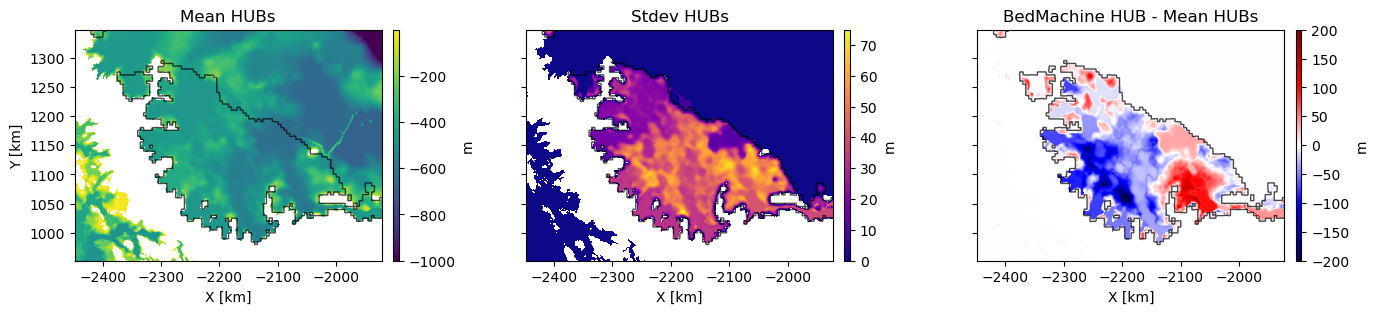

In [44]:
fig, axs = plt.subplots(1, 3, figsize=(16.5,3), sharey=True)
ax = axs[0]
im = ax.pcolormesh(xkm, ykm, mean_hubs, vmin=-1000, rasterized=True)
ax.contour(xkm, ykm, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Mean HUBs')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')

ax = axs[1]
im = ax.pcolormesh(xkm, ykm, std_hubs, vmin=0, cmap='plasma', rasterized=True)
ax.contour(xkm, ykm, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Stdev HUBs')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')

ax = axs[2]
im = ax.pcolormesh(xkm, ykm, hubs_bm-mean_hubs, vmin=-200, vmax=200, cmap='seismic', rasterized=True)
ax.contour(xkm, ykm, inv_dens, levels=[0], colors='k', antialiased=True, linewidths=1, alpha=0.7)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('BedMachine HUB - Mean HUBs')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')


plt.savefig(Path(f'../../figures/png/{name}_hubs.png'), dpi=300, bbox_inches='tight')
plt.savefig(Path(f'../../figures/svg/{name}_hubs.svg'), dpi=300, bbox_inches='tight')
plt.show()

In [39]:
target_cache = xr.open_dataarray(Path('results_gn/target_cache.nc')).values
target_cache.shape

(200, 80, 106)

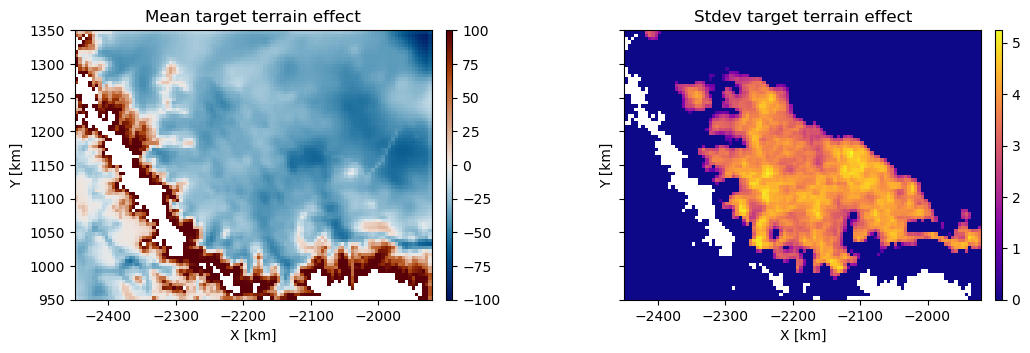

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(13,3.5), sharey=True)
ax = axs[0]
im = ax.pcolormesh(ds.x.values/1000, ds.y.values/1000, np.mean(target_cache, axis=0), vmin=-100, vmax=100, cmap=cm.vik, rasterized=True)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Mean target terrain effect')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x.values/1000, ds.y.values/1000, np.std(target_cache, axis=0), cmap='plasma', rasterized=True)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Stdev target terrain effect')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

plt.savefig(Path(f'../../figures/png/{name}_grav.png'), dpi=300, bbox_inches='tight')
plt.savefig(Path(f'../../figures/svg/{name}_grav.svg'), dpi=300, bbox_inches='tight')
plt.show()